# S&P 500 Volatility Forecasting
### Statistical and Machine-Learning Models for 20-Day Market Risk

This project tests whether recent market behavior can forecast **S&P 500 volatility over the next 20 trading days**. SPY is used as an investable S&P 500 proxy, and the VIX is included as a market-risk signal available at the forecast date.

The project compares simple benchmarks, traditional volatility models, and machine-learning models using an **expanding-window time-series validation design** and a completely untouched 2025 test period.


## Executive Summary

**Business question:** Can statistical and machine-learning models improve forecasts of near-term market volatility, and how reliable are those forecasts when markets become stressed?

**Approach:** Daily SPY and VIX data from 2010–2025 are used to predict annualized realized volatility over the following 20 trading days. Model selection is based on five expanding-window validation folds with a 20-trading-day purge between training and validation periods. The full 2025 period is held out until the end.

### Final 2025 test results

| Model | MAE (vol. pp) | RMSE (vol. pp) | QLIKE |
|---|---:|---:|---:|
| GARCH(1,1) | 7.22 | 11.54 | **0.567** |
| Random Forest | **6.57** | 11.10 | 0.624 |
| HAR-style | 6.86 | **10.95** | 0.639 |
| Gradient Boosting | 6.98 | 11.23 | 0.641 |
| Persistence | 8.46 | 13.31 | 0.667 |
| EWMA | 9.16 | 13.18 | 0.733 |

No single model dominates every metric. Random Forest produces the lowest average absolute error, HAR-style regression produces the lowest RMSE, and GARCH produces the best QLIKE score. Compared with the persistence benchmark, Random Forest reduces test MAE by about **22%**.

The most important risk finding is broader than the leaderboard: **all models become much less accurate when volatility is high and systematically underpredict the stressed regime.** This is why forecast models should complement—not replace—scenario-based stress testing.


## 1. Setup

The notebook uses `pandas` and `NumPy` for data preparation, `scikit-learn` for regression and tree models, `arch` for GARCH, `yfinance` for market data, and `matplotlib` for visualization.

For a portfolio notebook, dependencies are kept outside the analysis rather than installed mid-notebook. See `requirements.txt`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    make_scorer
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from arch import arch_model


## 2. Data Collection and Target Construction

SPY provides the equity-market price series. The VIX is included because it reflects the market's forward-looking expectation of S&P 500 volatility and is observable at the forecast date.

`auto_adjust=True` is used so SPY prices reflect distributions and corporate actions consistently through time.


In [ ]:
tickers = ["SPY", "^VIX"]

data = yf.download(
    tickers,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

df = pd.DataFrame(index=data.index)

df["SPY_Close"] = data["Close"]["SPY"]
df["SPY_High"] = data["High"]["SPY"]
df["SPY_Low"] = data["Low"]["SPY"]
df["SPY_Volume"] = data["Volume"]["SPY"]
df["VIX"] = data["Close"]["^VIX"]

print(
    f"Rows: {len(df):,} | "
    f"Start: {df.index.min().date()} | "
    f"End: {df.index.max().date()} | "
    f"Missing values: {int(df.isna().sum().sum())}"
)


### Log returns

A log return measures SPY's day-to-day price change using the natural logarithm.

**Plain-English formula**

`Log return = ln(Today's SPY close / Previous trading day's SPY close)`

**Example:** if SPY rises from 500 to 505, the log return is `ln(505 / 500) = 0.00995`, or about **0.995%**. The ordinary percentage return is 1.00%, so the two are very close for normal daily market moves.

Log returns are useful because they add cleanly across time and are standard in financial volatility modeling. The return itself is logged, but the final volatility estimate is not something we "back-transform." A volatility value of `0.20` is reported as **20% annualized volatility**.


In [ ]:
df["Log_Return"] = np.log(
    df["SPY_Close"] / df["SPY_Close"].shift(1)
)


### What volatility means

Volatility measures **how widely returns move**, regardless of whether prices move up or down. A quiet market has small daily returns; a turbulent market has much larger positive and negative returns.

A common historical-volatility measure is:

`Annualized volatility = standard deviation of daily returns × sqrt(252)`

This project uses a closely related realized-volatility measure based on **squared daily log returns**. Squaring removes direction, so a +3% day and a -3% day contribute equally to volatility. Large moves matter much more than small moves because they are squared.


### Forecast target: future 20-day realized volatility

For each trading date, the model predicts how volatile SPY will be over the **next 20 trading days**.

**Plain-English formula**

`Future 20D volatility = sqrt(252 × average of the next 20 squared daily log returns)`

**How the target is built**

| Step | What happens | Why it matters |
|---|---|---|
| 1 | `shift(-1)` through `shift(-20)` collect the next 20 daily returns | Creates a forward-looking target |
| 2 | Each future return is squared | Removes direction and measures movement size |
| 3 | The 20 squared returns are averaged and annualized to 252 trading days | Places the result on an annual volatility scale |
| 4 | The square root is taken | Converts the variance-like quantity back to volatility |

Only the **target** uses future returns. Every model feature uses information known on or before the forecast date. This separation is essential to avoid data leakage.


In [ ]:
future_squared_returns = sum(
    df["Log_Return"].shift(-i) ** 2
    for i in range(1, 21)
)

df["Future_20D_Volatility"] = np.sqrt(
    (252 / 20) * future_squared_returns
)

df["Future_20D_Volatility"].describe()


count    4004.000000
mean        0.146856
std         0.091158
min         0.032771
25%         0.092766
50%         0.124023
75%         0.174102
max         0.923201
Name: Future_20D_Volatility, dtype: float64

In [ ]:
(df["Future_20D_Volatility"] * 100).plot(
    figsize=(12, 6),
    linewidth=1.2
)

plt.title("Future 20-Day Realized Volatility of SPY")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.grid(True)
plt.show()


The target is strongly right-skewed. Median forward volatility is about **12.4%**, while extreme periods rise above **90% annualized**. That asymmetry is important: a model can perform well during ordinary markets yet still fail badly during abrupt stress.


## 3. Feature Engineering

The model uses information that would be available **after the market closes on each forecast date**. That includes the day's SPY return, high, low, volume, and VIX level, plus rolling measures calculated from past observations.

The goal is to represent five sources of information: recent market direction, recent volatility, market expectations, intraday stress, and trading activity.


In [ ]:
# Recent cumulative log returns
df["Return_1D"] = df["Log_Return"]

df["Return_5D"] = (
    df["Log_Return"]
    .rolling(window=5)
    .sum()
)

df["Return_20D"] = (
    df["Log_Return"]
    .rolling(window=20)
    .sum()
)

# Backward-looking realized volatility
df["Volatility_5D"] = np.sqrt(
    (252 / 5) *
    df["Log_Return"].pow(2).rolling(window=5).sum()
)

df["Volatility_20D"] = np.sqrt(
    (252 / 20) *
    df["Log_Return"].pow(2).rolling(window=20).sum()
)

df["Volatility_60D"] = np.sqrt(
    (252 / 60) *
    df["Log_Return"].pow(2).rolling(window=60).sum()
)

# VIX changes
df["VIX_Change_1D"] = df["VIX"].pct_change()
df["VIX_Change_5D"] = df["VIX"] / df["VIX"].shift(5) - 1

# Intraday stress and trading activity
df["High_Low_Range"] = np.log(
    df["SPY_High"] / df["SPY_Low"]
)

df["Volume_Change_1D"] = df["SPY_Volume"].pct_change()


| Feature group | Variables | Why they matter |
|---|---|---|
| Market direction | 1D, 5D, 20D returns | Captures recent gains, losses, and momentum/reversal behavior |
| Realized volatility | 5D, 20D, 60D volatility | Captures short-, medium-, and longer-term volatility persistence |
| Market expectations | VIX, 1D and 5D VIX changes | Measures current expected market risk and changes in risk sentiment |
| Intraday stress | High-low range | Captures unusually large within-day price movement |
| Trading activity | Volume change | Captures changes in market participation and activity |

The key distinction is **backward-looking features versus a forward-looking target**. `Volatility_20D` describes the recent past; `Future_20D_Volatility` describes the next 20 trading days.


In [ ]:
feature_columns = [
    "Return_1D",
    "Return_5D",
    "Return_20D",
    "Volatility_5D",
    "Volatility_20D",
    "Volatility_60D",
    "VIX",
    "VIX_Change_1D",
    "VIX_Change_5D",
    "High_Low_Range",
    "Volume_Change_1D"
]

model_df = df[
    feature_columns + ["Future_20D_Volatility"]
].dropna().copy()

print(
    f"Modeling rows: {len(model_df):,} | "
    f"Start: {model_df.index.min().date()} | "
    f"End: {model_df.index.max().date()}"
)


The modeling sample begins later than the raw data because the 60-day feature needs sufficient history. It ends on December 2, 2025 because the final 20 trading days do not have enough future observations to calculate the target.


## 4. Time-Series Validation Design

A random train/test split would be inappropriate because it could allow a model to learn from future market conditions. Instead, the project uses chronological splits.

The final 2025 period is completely withheld from model selection. A **20-trading-day purge** separates development and evaluation periods because each target itself contains the next 20 returns. Without that gap, a late training target could overlap the validation or test period.


In [ ]:
test_start = pd.Timestamp("2025-01-02")
test_start_pos = model_df.index.get_loc(test_start)

gap = 20

development_df = model_df.iloc[:test_start_pos - gap].copy()
gap_df = model_df.iloc[test_start_pos - gap:test_start_pos].copy()
test_df = model_df.iloc[test_start_pos:].copy()

split_summary = pd.DataFrame({
    "Period": ["Development", "20-day purge", "Final test"],
    "Start": [
        development_df.index.min().date(),
        gap_df.index.min().date(),
        test_df.index.min().date()
    ],
    "End": [
        development_df.index.max().date(),
        gap_df.index.max().date(),
        test_df.index.max().date()
    ],
    "Rows": [
        len(development_df),
        len(gap_df),
        len(test_df)
    ]
})

split_summary


The development sample contains 3,694 observations through December 2, 2024. The next 20 trading days are purged, and 230 observations from 2025 form the final test set.

Within the development sample, five expanding-window validation folds are used. Each fold trains on all history available up to that point, leaves a 20-day purge, and validates on approximately one trading year (252 observations).


In [ ]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=252,
    gap=20
)

fold_rows = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(development_df),
    start=1
):
    train = development_df.iloc[train_idx]
    val = development_df.iloc[val_idx]

    fold_rows.append({
        "Fold": fold,
        "Train start": train.index.min().date(),
        "Train end": train.index.max().date(),
        "Train rows": len(train),
        "Validation start": val.index.min().date(),
        "Validation end": val.index.max().date(),
        "Validation rows": len(val)
    })

pd.DataFrame(fold_rows)


   Fold Train start   Train end  Train rows Validation start Validation end  Validation rows
0     1  2010-03-31  2019-10-30        2414       2019-11-29     2020-11-27              252
1     2  2010-03-31  2020-10-29        2666       2020-11-30     2021-11-29              252
2     3  2010-03-31  2021-10-29        2918       2021-11-30     2022-11-29              252
3     4  2010-03-31  2022-10-31        3170       2022-11-30     2023-11-30              252
4     5  2010-03-31  2023-11-01        3422       2023-12-01     2024-12-02              252

The fold inspection is a one-time sanity check. It confirms that training always comes before validation, the training window expands through time, each validation block has 252 rows, and the 20-day purge is respected.


## 5. Evaluation Metrics

No single error metric tells the whole story, so the project uses three complementary measures.

| Metric | What it tells us | Better result |
|---|---|---|
| **MAE** | Average size of the forecast error | Lower |
| **RMSE** | Similar to MAE, but penalizes large misses more heavily | Lower |
| **QLIKE** | Volatility-specific loss based on predicted versus realized variance | Lower |

MAE and RMSE are reported in **annualized volatility percentage points** for readability. QLIKE remains on its own loss scale, where values closer to zero are better.


In [ ]:
def qlike(y_true, y_pred):
    actual_var = np.asarray(y_true) ** 2
    pred_var = np.clip(np.asarray(y_pred) ** 2, 1e-8, None)

    ratio = actual_var / pred_var
    return np.mean(ratio - np.log(ratio) - 1)


def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "QLIKE": qlike(y_true, y_pred)
    }


qlike_scorer = make_scorer(
    qlike,
    greater_is_better=False
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "QLIKE": qlike_scorer
}


def summarize_sklearn_cv(scores):
    return {
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "QLIKE": -scores["test_QLIKE"].mean()
    }


## 6. Simple Benchmarks: Persistence and EWMA

Before using more complex models, the project establishes two simple benchmarks.

| Benchmark | Forecast rule | Purpose |
|---|---|---|
| **Persistence** | Next 20-day volatility is assumed to equal the most recent 20-day volatility | Tests whether a complex model beats a simple "volatility persists" rule |
| **EWMA** | Recent squared returns receive more weight than older returns | Captures the tendency for recent volatility to matter more |

EWMA uses a standard decay factor of `0.94`, meaning older observations lose influence gradually over time.


In [ ]:
lambda_ = 0.94

ewma_variance = (
    df["Log_Return"]
    .pow(2)
    .ewm(alpha=1 - lambda_, adjust=False)
    .mean()
)

df["EWMA_Volatility"] = np.sqrt(
    252 * ewma_variance
)

development_df["EWMA_Volatility"] = df.loc[
    development_df.index,
    "EWMA_Volatility"
]

test_df["EWMA_Volatility"] = df.loc[
    test_df.index,
    "EWMA_Volatility"
]


def evaluate_rule_cv(data, prediction_col, splitter):
    fold_results = []

    for _, val_idx in splitter.split(data):
        val = data.iloc[val_idx]

        fold_results.append(
            evaluate_forecast(
                val["Future_20D_Volatility"],
                val[prediction_col]
            )
        )

    return pd.DataFrame(fold_results)


persistence_cv = evaluate_rule_cv(
    development_df,
    "Volatility_20D",
    tscv
)

ewma_cv = evaluate_rule_cv(
    development_df,
    "EWMA_Volatility",
    tscv
)

benchmark_summary = pd.DataFrame([
    {
        "Model": "Persistence",
        **persistence_cv.mean().to_dict()
    },
    {
        "Model": "EWMA",
        **ewma_cv.mean().to_dict()
    }
])

benchmark_summary


The benchmarks are intentionally simple. Their purpose is not to win; they establish the minimum performance that more complicated models should improve upon.


## 7. HAR-Style Volatility Regression

The HAR-style model asks whether volatility over different recent horizons helps explain the next 20 trading days.

**Model structure**

`Predicted 20D volatility = intercept + b1(5D volatility) + b2(20D volatility) + b3(60D volatility)`

This gives the model short-, medium-, and longer-horizon views of recent market risk. It is described as **HAR-style** rather than textbook HAR-RV because this project uses daily SPY returns rather than high-frequency intraday realized-variance data.


In [ ]:
har_features = [
    "Volatility_5D",
    "Volatility_20D",
    "Volatility_60D"
]

X_har = development_df[har_features]
y_dev = development_df["Future_20D_Volatility"]

har_model = LinearRegression()

har_scores = cross_validate(
    har_model,
    X_har,
    y_dev,
    cv=tscv,
    scoring=scoring
)

har_cv_summary = summarize_sklearn_cv(har_scores)

har_cv_summary


In [ ]:
har_model.fit(X_har, y_dev)

har_coefficients = pd.DataFrame({
    "Feature": har_features,
    "Coefficient": har_model.coef_
})

print("Intercept:", round(har_model.intercept_, 6))
har_coefficients


Intercept: 0.060758


             Feature  Coefficient
0      Volatility_5D     0.395463
1     Volatility_20D     0.101625
2     Volatility_60D     0.104514

The fitted regression places the largest weight on **5-day volatility**, indicating that very recent market conditions carry the strongest predictive signal in this specification. The 20- and 60-day measures still add longer-horizon context.

Because these rolling windows overlap, the coefficients should be interpreted as **predictive weights**, not isolated causal effects.


## 8. GARCH(1,1)

GARCH models volatility as a process that changes through time. The basic idea is straightforward:

`Today's variance = baseline + effect of yesterday's shock + effect of yesterday's variance`

The two most important fitted parameters are:

| Parameter | Interpretation |
|---|---|
| **alpha** | How strongly a new market shock changes volatility |
| **beta** | How strongly the previous volatility level carries forward |

Returns are multiplied by 100 inside the `arch` package for numerical stability. Forecasts are converted back to decimal volatility before evaluation so they remain directly comparable with the other models.


In [ ]:
garch_returns = (
    df.loc[development_df.index, "Log_Return"] * 100
)

garch_cv_rows = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(development_df),
    start=1
):
    val = development_df.iloc[val_idx]

    # arch excludes last_obs itself, so this is the first date
    # immediately after the training sample.
    last_obs = development_df.index[train_idx[-1] + 1]

    model = arch_model(
        garch_returns,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    result = model.fit(
        last_obs=last_obs,
        disp="off"
    )

    forecasts = result.forecast(
        horizon=20,
        start=val.index[0],
        reindex=False
    )

    variance_forecasts = forecasts.variance.loc[val.index]

    y_pred = (
        np.sqrt(
            252 * variance_forecasts.mean(axis=1)
        )
        / 100
    )

    y_true = val["Future_20D_Volatility"]

    garch_cv_rows.append({
        "Fold": fold,
        **evaluate_forecast(y_true, y_pred)
    })

garch_results = pd.DataFrame(garch_cv_rows)
garch_cv_summary = (
    garch_results[["MAE", "RMSE", "QLIKE"]]
    .mean()
    .to_dict()
)

garch_results


,Fold,MAE,RMSE,QLIKE
0,1,0.110565,0.189813,1.637907
1,2,0.036947,0.043946,0.205459
2,3,0.053099,0.065340,0.213175
3,4,0.027534,0.034105,0.104883
4,5,0.035551,0.043098,0.190762


In [ ]:
garch_model = arch_model(
    garch_returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_fit = garch_model.fit(disp="off")

garch_parameter_table = pd.DataFrame({
    "Coefficient": garch_fit.params,
    "Std. Error": garch_fit.std_err,
    "t-stat": garch_fit.tvalues,
    "p-value": garch_fit.pvalues
})

alpha = garch_fit.params["alpha[1]"]
beta = garch_fit.params["beta[1]"]

display(garch_parameter_table)
print("Alpha + Beta:", round(alpha + beta, 4))


The fitted GARCH model estimates `alpha = 0.156` and `beta = 0.813`. Their sum is approximately `0.968`.

Because `alpha + beta` is close to 1, volatility shocks are **highly persistent**: a large market shock raises volatility quickly, and that elevated risk tends to fade gradually rather than disappear immediately. Because the sum is still below 1, the fitted process remains mean-reverting rather than permanently explosive.


## 9. Machine-Learning Models

The machine-learning models use all engineered features, including returns, realized volatility, VIX, intraday range, and volume change.

Two nonlinear tree approaches are compared:

- **Random Forest:** averages many trees to reduce variance and capture nonlinear interactions.
- **Histogram Gradient Boosting:** builds trees sequentially, with later trees focusing on errors made earlier.

Hyperparameters are fixed before the final test evaluation; the 2025 test set is not used for tuning.


In [ ]:
ml_features = feature_columns

X_ml = development_df[ml_features]

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    random_state=42
)

rf_scores = cross_validate(
    rf_model,
    X_ml,
    y_dev,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1
)

gb_scores = cross_validate(
    gb_model,
    X_ml,
    y_dev,
    cv=tscv,
    scoring=scoring
)

rf_cv_summary = summarize_sklearn_cv(rf_scores)
gb_cv_summary = summarize_sklearn_cv(gb_scores)

pd.DataFrame([
    {"Model": "Random Forest", **rf_cv_summary},
    {"Model": "Gradient Boosting", **gb_cv_summary}
])


## 10. Cross-Validation Comparison

Model selection is based only on the development-period validation folds. MAE and RMSE are shown in **annualized volatility percentage points** for readability; QLIKE remains in its native loss scale.


In [ ]:
leaderboard = pd.DataFrame([
    {
        "Model": "Persistence",
        **persistence_cv.mean().to_dict()
    },
    {
        "Model": "EWMA",
        **ewma_cv.mean().to_dict()
    },
    {
        "Model": "HAR-style",
        **har_cv_summary
    },
    {
        "Model": "GARCH(1,1)",
        **garch_cv_summary
    },
    {
        "Model": "Random Forest",
        **rf_cv_summary
    },
    {
        "Model": "Gradient Boosting",
        **gb_cv_summary
    }
])

cv_display = leaderboard.copy()
cv_display["MAE (vol. pp)"] = cv_display.pop("MAE") * 100
cv_display["RMSE (vol. pp)"] = cv_display.pop("RMSE") * 100

cv_display.sort_values("QLIKE").reset_index(drop=True)


### Development-period findings

| Metric | Best model | Result |
|---|---|---:|
| MAE | HAR-style | 5.09 vol. pp |
| RMSE | GARCH(1,1) | 7.53 vol. pp |
| QLIKE | GARCH(1,1) | 0.470 |

The simple benchmarks are useful but weaker. Random Forest is competitive, while Gradient Boosting does not improve on the strongest statistical models. At this stage, no model is changed based on what might happen in 2025.


## 11. Untouched 2025 Test

After model comparison is complete, the models are evaluated once on the 2025 test set.

For supervised models, training uses only the development sample. The 20-day purge prevents forward-looking training targets from overlapping 2025. GARCH parameters are also estimated only through the development period; its volatility state can update with returns that have already been observed by each test-date forecast origin.


In [ ]:
# Supervised model forecasts
har_final = LinearRegression().fit(
    development_df[har_features],
    y_dev
)

rf_final = rf_model.fit(
    development_df[ml_features],
    y_dev
)

gb_final = gb_model.fit(
    development_df[ml_features],
    y_dev
)

har_test_pred = har_final.predict(
    test_df[har_features]
)

rf_test_pred = rf_final.predict(
    test_df[ml_features]
)

gb_test_pred = gb_final.predict(
    test_df[ml_features]
)

# Rule-based forecasts
persistence_test_pred = test_df["Volatility_20D"]
ewma_test_pred = test_df["EWMA_Volatility"]

y_test = test_df["Future_20D_Volatility"]


In [ ]:
# Build a return series that extends through the test dates.
# GARCH parameters are estimated only through the development period.
garch_test_returns = (
    df.loc[
        development_df.index.min():test_df.index.max(),
        "Log_Return"
    ] * 100
)

final_garch_model = arch_model(
    garch_test_returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

final_garch_fit = final_garch_model.fit(
    last_obs=gap_df.index[0],
    disp="off"
)

garch_forecasts = final_garch_fit.forecast(
    horizon=20,
    start=test_df.index[0],
    reindex=False
)

garch_test_variance = (
    garch_forecasts.variance.loc[test_df.index]
)

garch_test_pred = (
    np.sqrt(
        252 * garch_test_variance.mean(axis=1)
    )
    / 100
)

assert len(garch_test_pred) == len(y_test)


In [ ]:
test_results = pd.DataFrame([
    {
        "Model": "Persistence",
        **evaluate_forecast(y_test, persistence_test_pred)
    },
    {
        "Model": "EWMA",
        **evaluate_forecast(y_test, ewma_test_pred)
    },
    {
        "Model": "HAR-style",
        **evaluate_forecast(y_test, har_test_pred)
    },
    {
        "Model": "GARCH(1,1)",
        **evaluate_forecast(y_test, garch_test_pred)
    },
    {
        "Model": "Random Forest",
        **evaluate_forecast(y_test, rf_test_pred)
    },
    {
        "Model": "Gradient Boosting",
        **evaluate_forecast(y_test, gb_test_pred)
    }
])

test_display = test_results.copy()
test_display["MAE (vol. pp)"] = test_display.pop("MAE") * 100
test_display["RMSE (vol. pp)"] = test_display.pop("RMSE") * 100

test_display.sort_values("QLIKE").reset_index(drop=True)


               Model     QLIKE  MAE (vol. pp)  RMSE (vol. pp)
0         GARCH(1,1)  0.566619       7.2160          11.5408
1      Random Forest  0.624138       6.5736          11.1018
2          HAR-style  0.638884       6.8639          10.9543
3  Gradient Boosting  0.640799       6.9785          11.2342
4        Persistence  0.667421       8.4608          13.3109
5               EWMA  0.732593       9.1574          13.1796

### Final test interpretation

There is **no single winner across all three metrics**:

- **Random Forest** has the lowest MAE at 6.57 volatility percentage points.
- **HAR-style** has the lowest RMSE at 10.95 percentage points.
- **GARCH(1,1)** has the best QLIKE at 0.567 and remains the strongest model when variance-specific accuracy is emphasized.

The ranking shift from cross-validation to 2025 is a useful result in itself. It shows why a final untouched test period matters: a model that looks strongest on development data may not dominate under a new market regime.


## 12. Where the Models Fail: 2025 Stress Episode

The three strongest and most distinct models are plotted against actual forward 20-day volatility. This makes forecast behavior easier to evaluate than summary metrics alone.


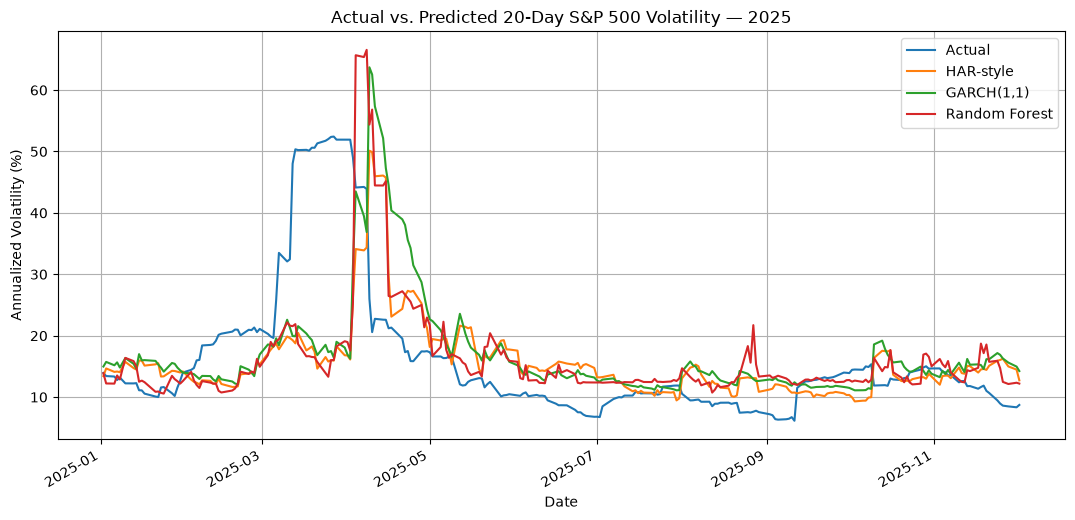

In [ ]:
forecast_df = pd.DataFrame({
    "Actual": y_test,
    "HAR-style": har_test_pred,
    "GARCH(1,1)": np.asarray(garch_test_pred),
    "Random Forest": rf_test_pred
}, index=y_test.index)

(forecast_df * 100).plot(
    figsize=(13, 6),
    linewidth=1.5
)

plt.title("Actual vs. Predicted 20-Day S&P 500 Volatility — 2025")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
(
    forecast_df
    .nlargest(10, "Actual")
    .mul(100)
    .round(2)
)


,Actual,HAR-style,"GARCH(1,1)",Random Forest
Date,,,,
2025-03-27,52.43,15.93,16.44,16.05
2025-03-26,52.38,16.03,17.49,16.01
2025-03-25,52.03,15.79,17.32,13.31
2025-03-28,51.93,18.28,19.00,18.26
2025-04-02,51.93,16.12,16.27,17.57
2025-03-31,51.92,16.81,18.06,19.10
2025-04-01,51.91,16.78,16.95,18.96
2025-03-24,51.75,16.51,18.51,13.91
2025-03-21,51.32,14.63,16.84,15.72


The largest realized 20-day volatility readings exceed **50% annualized**, while the leading forecasts remain mostly in the mid-to-high teens. All three models therefore **substantially underpredict the abrupt volatility regime shift**.

These ten rows should not be interpreted as ten independent crises. The target uses overlapping 20-day windows, so nearby forecast dates share many of the same future returns.


## 13. Regime Analysis

To test whether forecast quality changes when markets become stressed, the high-volatility threshold is defined using the **75th percentile of development-period forward volatility**. This avoids choosing a threshold after seeing the 2025 test outcomes.

In this sample, the threshold is approximately **17.48% annualized volatility**.


In [ ]:
stress_threshold = development_df[
    "Future_20D_Volatility"
].quantile(0.75)

test_forecasts = pd.DataFrame({
    "Actual": y_test,
    "Persistence": persistence_test_pred,
    "EWMA": ewma_test_pred,
    "HAR-style": har_test_pred,
    "GARCH(1,1)": np.asarray(garch_test_pred),
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_test_pred
}, index=y_test.index)

absolute_errors = (
    test_forecasts
    .drop(columns="Actual")
    .sub(test_forecasts["Actual"], axis=0)
    .abs()
)

absolute_errors["Regime"] = np.where(
    test_forecasts["Actual"] >= stress_threshold,
    "High Volatility",
    "Normal Volatility"
)

regime_mae = (
    absolute_errors
    .groupby("Regime")
    .mean()
    .T
)

signed_errors = (
    test_forecasts
    .drop(columns="Actual")
    .sub(test_forecasts["Actual"], axis=0)
)

signed_errors["Regime"] = absolute_errors["Regime"]

regime_bias = (
    signed_errors
    .groupby("Regime")
    .mean()
    .T
)

print(
    "Stress threshold:",
    f"{stress_threshold * 100:.2f}%"
)

print("\nRegime counts:")
display(absolute_errors["Regime"].value_counts())

print("\nMAE by regime (volatility percentage points):")
display((regime_mae * 100).round(2))

print("\nAverage forecast bias by regime (percentage points):")
display((regime_bias * 100).round(2))


### Regime findings

| Model | High-volatility MAE | Normal-volatility MAE | High-volatility bias |
|---|---:|---:|---:|
| Persistence | 20.13 | 5.05 | -8.83 |
| EWMA | 19.66 | 6.09 | -9.70 |
| HAR-style | **17.45** | 3.77 | -11.60 |
| GARCH(1,1) | 18.30 | 3.98 | **-8.48** |
| Random Forest | 18.26 | **3.16** | -9.48 |
| Gradient Boosting | 17.97 | 3.77 | -9.88 |

There are **178 normal-volatility observations** and **52 high-volatility observations** in the test sample.

Every model shifts from a small positive bias in normal markets to a large negative bias in the high-volatility regime. In practical terms, the models tend to **slightly overestimate ordinary risk but materially underestimate stressed risk**.


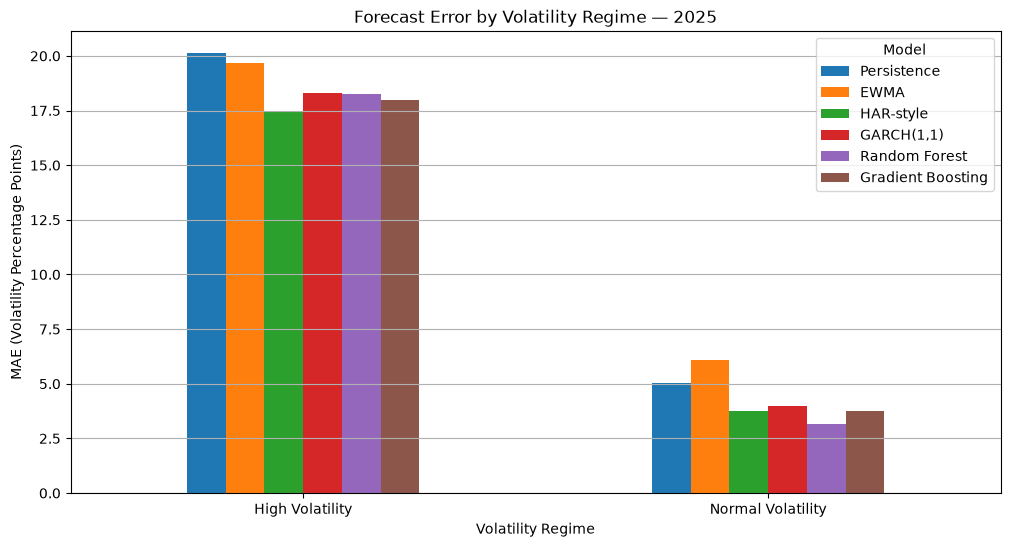

In [ ]:
regime_plot = regime_mae.T * 100

regime_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Forecast Error by Volatility Regime — 2025")
plt.xlabel("Volatility Regime")
plt.ylabel("MAE (Volatility Percentage Points)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Model")
plt.show()


## 14. Key Findings

1. **More complexity does not guarantee better forecasts.** HAR-style regression and GARCH remain highly competitive with tree-based machine learning.
2. **Model rankings depend on the loss function.** Random Forest wins MAE, HAR-style wins RMSE, and GARCH wins QLIKE on the final test.
3. **The simple persistence and EWMA benchmarks are meaningfully weaker**, confirming that the richer models add predictive value.
4. **Forecast accuracy deteriorates sharply in high-volatility regimes.** Normal-regime MAE is roughly 3–6 percentage points, while stressed-regime MAE rises to roughly 17–20 points.
5. **All models systematically underpredict stress.** This is the main risk-management finding and directly motivates scenario-based stress testing.


## 15. Risk-Management Interpretation and Stress-Testing Relevance

A volatility forecast answers:

> **What level of market risk appears most likely given current information?**

A stress test answers a different question:

> **What happens if market conditions become much worse than the forecast?**

The 2025 results show why both are needed. Even the strongest models failed to anticipate the full size of the abrupt volatility spike. A future portfolio stress-testing project can use this work as a baseline risk model, then impose hypothetical or historical shocks well beyond the point forecast—for example, volatility regimes of 30%, 50%, or higher—to estimate portfolio losses under severe conditions.

The forecasting model should therefore be viewed as a **baseline risk estimate**, not a substitute for stress scenarios.


## 16. Limitations

- SPY is an investable proxy for the S&P 500 rather than the official S&P 500 Total Return Index.
- Realized volatility is estimated from daily squared log returns; high-frequency intraday data would provide a richer realized-variance measure.
- Forward 20-day targets overlap, so neighboring observations are correlated and regime counts are not independent stress events.
- The final test covers one calendar year. Results could differ across other out-of-sample periods.
- GARCH is estimated with a normal innovation distribution; alternative specifications such as Student-t, EGARCH, or GJR-GARCH could be tested in future work.
- Tree-model hyperparameters are intentionally restrained rather than exhaustively optimized. No model is tuned using the final 2025 test outcomes.


## 17. Reproducibility

**Core packages:** `pandas`, `numpy`, `matplotlib`, `yfinance`, `scikit-learn`, and `arch`.

The notebook is designed to run top-to-bottom in a fresh Python environment. The final 2025 test set should remain untouched until model specifications have been finalized using the development-period cross-validation results.
